# Numerical Simulation Laboratory (NSL) 
## Numerical exercises 2

### Exercise 02.1
- Compute the following 1D integral via Monte Carlo 
$$I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx = 1$$
1. sampling a uniform distribution in $[0,1]$
2. using importance sampling (i.e. sampling a non-uniform probability in $[0,1]$)

Show a picture of both your estimations of $I$ and their uncertainties with a large number of *throws* $M$ (e.g. $M\ge 10^4$) as a function of the number of blocks, $N$.

### Monte Carlo Integrals
To calculate an integral, Monte Carlo methods use random sampling to approximate the mean value of a function. In fact, an integral $I=\int_a^b f(x) dx$ can be interpreted as the product of the interval length and the mean value of the function over the interval. We can take $N$ random variables $x_i$ uniformly distributed between $a$ and $b$ and evaluate the integral as
$$I = |a-b| \langle f\rangle \simeq |a-b| \frac{1}{N}\sum_{i=1}^Nf(x_i) \, .$$

If we also have a non negative probability density function $p(x)$, normalized over a domain $\Omega$ ($\int_{\Omega}p(x)=1$), such that $I=\int_{\Omega} p(x)f(x)dx$, we can generalize the method described before. We can define an estimator $G_N$ as the simple average of the function $g(x)$ sampled from the distribution $p(x)$
$$G_N = \frac{1}{N}\sum_{i=1}^N g(x_i) \, .$$
We remind that in Monte Carlo integration methods there is a statistical predictible error $\epsilon$, which scales as $\sim N^{-1/2}$ as
$$\epsilon = \frac{\sigma_I}{\sqrt{N}}\\, ,$$
where $\sigma_I^2=\int_{\Omega} (g(x))^2p(x)dx - I^2$ is the intrinsic variance of the function. We can aim to a specific precision $\epsilon$ by fixing $N=\frac{\sigma_I^2}{\epsilon^2}$.  

### Importance Sampling
The importance sampling integration method introduces an auxiliary non-negative and normalized distribution $d(\vec x)$ which states where the integrand is more significant. We have
$$I=\int \left(\frac{g(\vec{x})p(\vec{x})}{d(\vec{x})}\right) g(\vec{x})d\vec{x} \, \, , \, \, G_N = \frac{1}{N}\sum_{i=1}{N} \frac{g(\vec{x}_i)p(\vec{x}_i)}{d(\vec{x}_i)} \, .$$

By finding the right $d(\vec x)$ it is possible to minimize the variance of the integral evaluation, which is now defined as
$$var[I]_d = \int \left(\frac{g(\vec{x})p(\vec{x})}{d(\vec{x})}\right)^2 g(\vec{x})d\vec{x} - I^2 \, .$$

We can use the Lagrange Multipliers method to minimize the integral with the constraint that $d(\vec{x})$ is normalized. It can be shown that the optimal distribution $d(\vec x)$ is proportional to the absolute value of the original integrand $d(\vec x) = \lambda |g(\vec x) p(\vec x)|$.

### Inverse Cumulative

We choose a linear probability density function $d(x)$ which have the same behavior of the cosine in $x \in [0,1]$
$$d(x) = 2(1-x) \, .$$
To sample a random variable with d(x) we need to use the inverse cumulative method, so
$$F(x) = \int_0^x2(1-x')dx' = x(2-x) =: u \, ,$$
where $u$ is the random variable uniformly distributed in $[0,1)$. By performing the inversion we obtain
$$x=1-\sqrt{1-u} \, .$$

### Comparison Between Methods

In this exercise we compare the standard Monte Carlo method (sampling of a uniform variable with rnd.Rannyu() and averaging the function values) with the Importance Sampling variant. With the Importance Sampling meethod we sample a random variable with the $d(x)=2(1-x)$ previously described and we evaluate the ratio 
$$\frac{f(x)}{d(x)}=\frac{\frac{\pi}{2}\cos(\pi x/2)}{2(1-x)} \, ,$$
which is going to be nearly constat (because of the choice we made on $d(x)$).

We also use the Data Blocking method with $M=10^5$ throws divided into $N=100$ blocks ($L=M/N=1000$ throws per block). As expected, the Importance Sampling method converges faster with a significant smaller statistical error.

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.gridspec as gridspec

from scipy.stats import norm
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d.art3d import Line3DCollection

plt.style.use('default')
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

color=plt.cm.inferno(0.5)
color2=plt.cm.inferno(0.2)

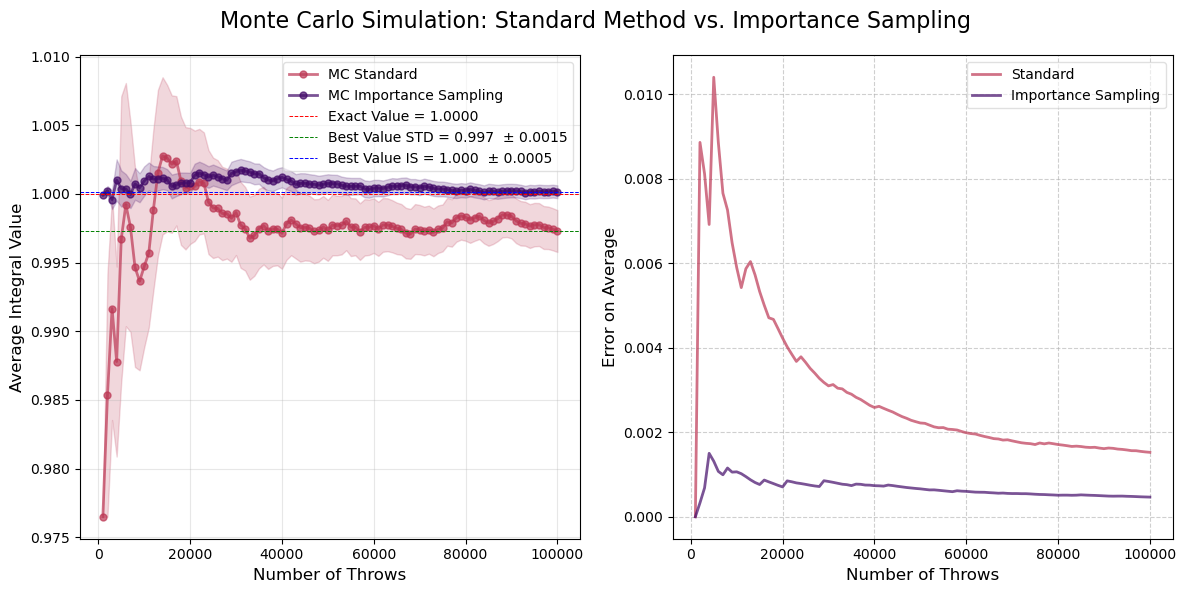

In [4]:
# Integral Value and its error
avg_standard = "ex02.1/out_avg.data"
avg_imp_samp = "ex02.1/out_imp_samp.data"
x1, y1, error1 = np.loadtxt(avg_standard, usecols=(0,1,2), delimiter='\t', unpack=True)
x2, y2, error2 = np.loadtxt(avg_imp_samp, usecols=(0,1,2), delimiter='\t', unpack=True)

x3, y3 = np.loadtxt(avg_standard, usecols=(0,2), delimiter='\t', unpack=True)
x4, y4 = np.loadtxt(avg_imp_samp, usecols=(0,2), delimiter='\t', unpack=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Average Integral Value with Error Band
ax[0].plot(x1, y1, 'o-', color=color, alpha=0.7, markersize=5, label='MC Standard')
ax[0].fill_between(x1, y1-error1, y1+error1, color=color, alpha=0.2)
ax[0].plot(x2, y2, 'o-', color=color2, alpha=0.7, markersize=5, label='MC Importance Sampling')
ax[0].fill_between(x2, y2-error2, y2+error2, color=color2, alpha=0.2)
ax[0].axhline(y=1, color='red', linestyle='--', linewidth=0.7, label=rf'Exact Value = {1:.4f}')
ax[0].axhline(y=y1[99], color='green', linestyle='--', linewidth=0.7, label=f'Best Value STD = {y1[99]:.3f}  ± {error1[99]:.4f}')
ax[0].axhline(y=y2[99], color='blue', linestyle='--', linewidth=0.7, label=f'Best Value IS = {y2[99]:.3f}  ± {error2[99]:.4f}')
ax[0].set_xlabel('Number of Throws')
ax[0].set_ylabel('Average Integral Value')
ax[0].legend(loc='upper right', frameon=True, fancybox=True, facecolor='white', fontsize=10, framealpha=0.6)
ax[0].grid(alpha=0.3)
ax[0].tick_params(axis='x')

# Plot 2: Error on Average
ax[1].plot(x3, y3, color=color, alpha=0.7, label='Standard')
ax[1].plot(x4, y4, color=color2, alpha=0.7, label='Importance Sampling')
ax[1].set_xlabel('Number of Throws')
ax[1].set_ylabel('Error on Average')
ax[1].grid(True, alpha=0.6, linestyle='--')
ax[1].legend(loc='upper right', frameon=True, fancybox=True, facecolor='white', fontsize=10, framealpha=0.6)

fig.suptitle('Monte Carlo Simulation: Standard Method vs. Importance Sampling', fontsize=16)

plt.tight_layout()
plt.show()

### Exercise 02.2
- 3D Random Walks (RW) on a cubic lattice and in the continuum: Repeat many times (e.g. say $10^4$) the simulation of a random walk in 3D always starting at the origin

1. on a cubic lattice with lattice constant $a=1$; at each discrete time the walker makes a forward or backward step of length equal to $a$ in one of the 3 principal directions of the lattice: $x$, $y$ or $z$
2. in the continuum; at each discrete time the walker makes a step of length equal to $a(=1)$ along a **random direction** obtained by sampling **uniformly** the solid angle: $\theta \in [0,\pi]$ and $\phi \in [0,2\pi]$

Show a picture of $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ for both RWs, with their statistical uncertainties, as function of the step $i\in [0,10^2]$.

Suggestion: divide your $M$ throws into a reasonable number of blocks, compute $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ as function of the step $i\in [0,10^2]$ in each block and use these values (for fixed $i$) to obtain the average value and its statistical uncertainty.

Note that you could try to fit both results with a function like $f(N)=k\sqrt{N}$. Do your results indicate a diffusive behavior?

### Random Walks

A Random Walk is a stochastic process defined by a family of random variables $\left(X_t\right)_{t \in I}$, which can be discrete in time if $I = \mathbb{N}$ or continuous if  $I = \mathbb{R}$.

A Random Walk is a Markov Process, defined by the fact that a future state depends only on the current one. For a sequence $t_0 < t_1 < ... < t_n$ we have
$$p_{1|n-1}(x_n,t_n|x_1,t_1;...;x_{n-1},t_{n-1}) = p_{1|1}(x_n,t_n|x_{n-1},t_{n-1}) \, ,$$
so we can write the $n-$ point joint probability distribution as a product of transitions
$$p(x_1,t_1;...;x_n,t_n) = p_1(x_1,t_1)\prod_{i=2}^n p_{1|1}(x_i,t_i|x_{i-1},t_{i-1}) \, .$$

In a Random Walk on a lattice with spacing $a$ and a time interval $\tau$ for each step, the probbility of finding the particle at $na$ after $s+1$ steps is determined by
$$p_1(na,(s+1)\tau) = \sum_{m=-\infty}^{\infty}p_{1|1}(na,(s+1)\tau|ma,s\tau)p_1(ma,s\tau) \, ,$$
and when we consider the continuoum limit $a \rightarrow 0$, $\tau \rightarrow 0$ we obtain the diffusion equation for $p_1(x,t)$
$$\frac{\partial p_1(x,t)}{\partial t} = \frac{a^2}{2\tau}\frac{\partial ^2 p_1(x,t)}{\partial x^2} , ,$$
where we can define the diffusion coefficient $D=\frac{a^2}{2\tau}$. By assuming a delta distribution $\delta(x)$ as a starting probability distribution, we obtain as solution of the diffusion equation 
$$p_1(x,t) = \frac{\exp{\left(-\frac{x^2}{4 D t}\right)}}{\sqrt{4\pi D t}} \, ,$$
which is a Gaussian distribution with zero mean and variance $2Dt$. As a consequence, for both discrete and continuous random walk, we expect for the Root Mean Square distance $\sqrt{\langle|r_N|^2\rangle}$ a linear scaling with the number of steps $N$
$$\sqrt{\langle|r_N|^2\rangle} = k \sqrt{N} \, .$$ 


### Comment on Continuous Random Walk
Since the walker, at each step, can move freely in a 3D space by a step of lenght $a$, we need to make sure that the distribution for the direction is uniform on a sphere. Thus, we need to sample $\cos{(\theta)}$ uniformly in $[-1,1]$ (and not directly $\theta$ uniformly in $[0,\pi)$, otherwise we would have a greater possibility to move upward or downward at each step).

### Data Blocking
To avoid correlation on sampled points, we use Data Blocking with $M=10^4$ different Random Walk divided in $N=100$ blocks ($L=M/N=100$ independent random walks in each block). Every independent trajectory is choosen to be $100$ steps loong. To be more exhaustive we have $100$ blocks, where in each of them we perform $100$ random walks of $100$ steps. The square distance is recorded for every trajectory and then averaged for each block $b_i$
$$\langle r^2\rangle _{b_i} = \frac{1}{L}\sum_{j=1}^Lr_j^2 \, \, , \, \, b_i \in {b_1,...,b_N} \, . $$

In [13]:
# Fit function
def fit(n,k):
    return k*np.sqrt(n)

# Step Size
a = 1

# Colored Line
def colored_line(ax, data, cmap="inferno", linewidth=2, alpha=0.8):
    from matplotlib.colors import Normalize
    from matplotlib.cm import ScalarMappable
    # Segments 
    points = np.array([data[:, 1], data[:, 2], data[:, 3]]).T
    segments = np.array([[points[i], points[i + 1]] for i in range(len(points) - 1)])
    # Colormap
    norm = Normalize(vmin=0, vmax=len(data))
    sm = ScalarMappable(norm=norm, cmap=cmap)
    colors = sm.to_rgba(np.arange(len(segments)))
    # Add Segments to Graph
    for i, segment in enumerate(segments):
        ax.plot(segment[:, 0], segment[:, 1], segment[:, 2], color=colors[i], linewidth=linewidth, alpha=alpha)


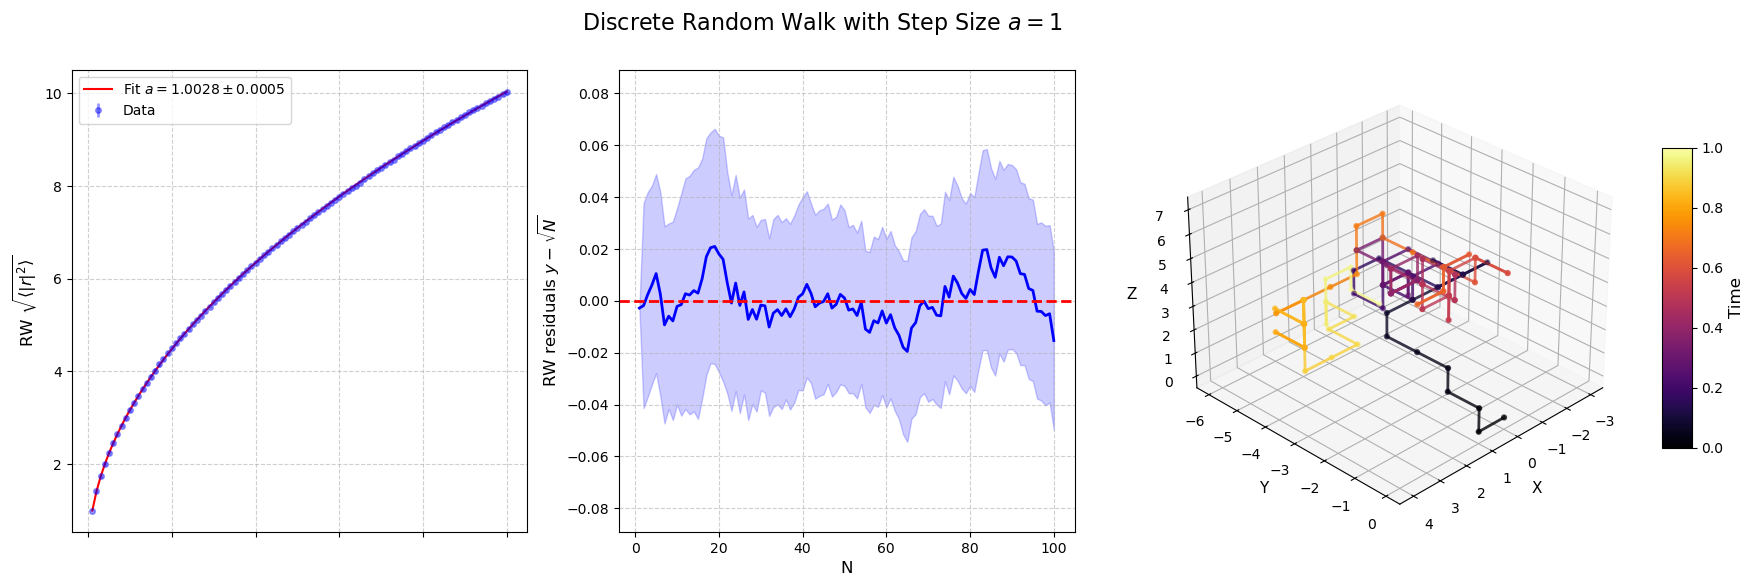

In [20]:
# Discrete Random Walk
fig = plt.figure(figsize=(20, 6))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1])

# Fit
x, y, err = np.loadtxt("ex02.2/out_avg_discrete.data", usecols=(0, 1, 2), delimiter='\t', unpack=True)
popt, pcov = curve_fit(fit, x[2:], y[2:], sigma=err[2:], absolute_sigma=True)
res = y - popt[0] * np.sqrt(x)
perr = np.sqrt(np.diag(pcov))

ax1 = fig.add_subplot(gs[0])
ax1.plot(x, fit(x, *popt), 'r-', linewidth=1.5, 
         label=rf'Fit $a={popt[0]:.4f} \pm {perr[0]:.4f}$')
ax1.errorbar(x, y, yerr=err, fmt='o', markersize=4, color='blue', alpha=0.4, label='Data')
ax1.tick_params(axis='x', labelbottom=False)
ax1.set_ylabel(r'RW $\sqrt{\langle|r|^2\rangle}$')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Residuals
ax2 = fig.add_subplot(gs[1])
ax2.plot(x, res, color='blue')
ax2.fill_between(x, res - err, res + err, color='blue', alpha=0.2)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_xlabel('N')
ax2.set_ylim(-0.089, 0.089)
ax2.set_ylabel(r'RW residuals $y - \sqrt{N}$')
ax2.grid(True, linestyle='--', alpha=0.6)

# 3D RW
data = np.loadtxt("ex02.2/discrete_traj.data")
ax3 = fig.add_subplot(gs[2], projection='3d')

cmap = "inferno"
colors = np.linspace(0, 1, len(data))

sc = ax3.scatter(data[:, 1], data[:, 2], data[:, 3],
                 c=colors, cmap=cmap, s=12)

colored_line(ax3, data, cmap=cmap, linewidth=2, alpha=0.8)

ax3.set_xlabel("X", fontsize=11)
ax3.set_ylabel("Y", fontsize=11)
ax3.set_zlabel("Z", fontsize=11)
ax3.view_init(elev=30, azim=45)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("Time", fontsize=12)
plt.suptitle(f'Discrete Random Walk with Step Size $a=1$', fontsize=16)
#plt.tight_layout()
plt.show()

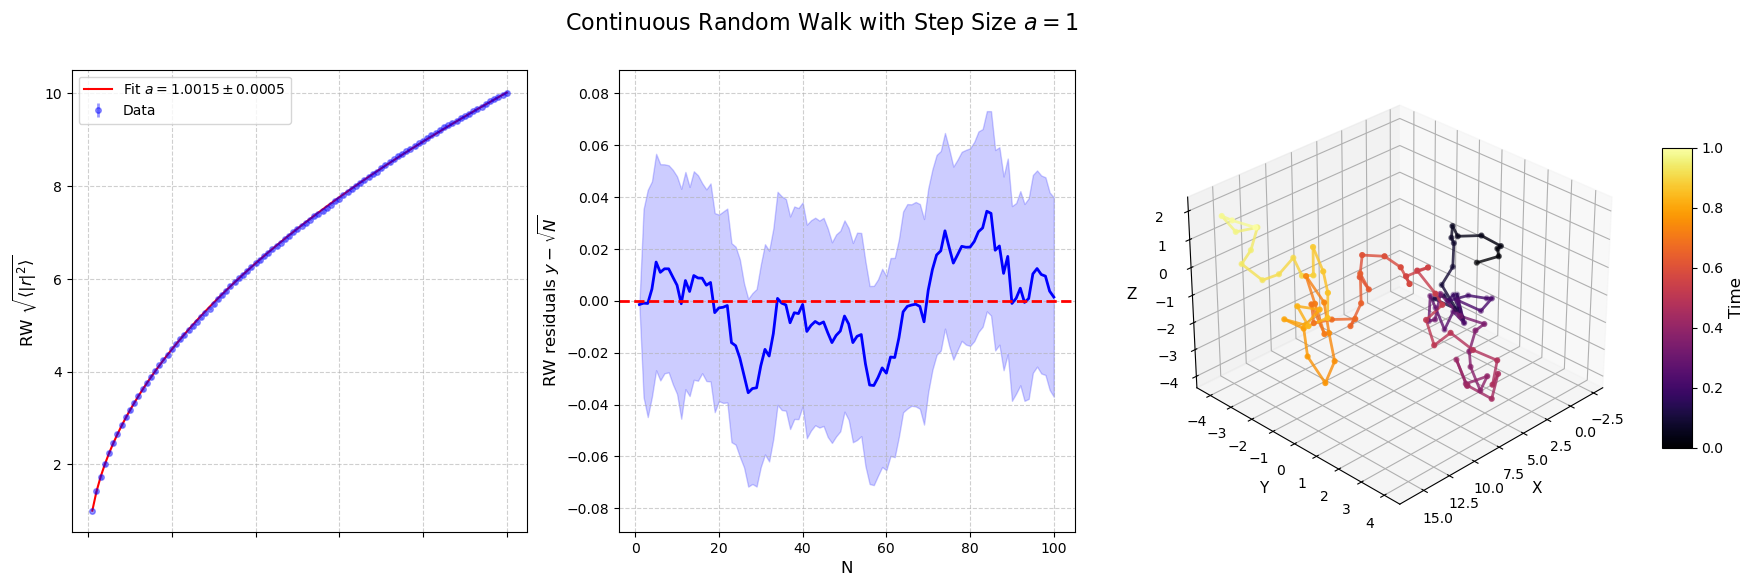

In [21]:
# Continuous Random Walk
fig = plt.figure(figsize=(20, 6))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1])

# Fit
x, y, err = np.loadtxt("ex02.2/out_avg_continuous.data", usecols=(0, 1, 2), delimiter='\t', unpack=True)
popt, pcov = curve_fit(fit, x[2:], y[2:], sigma=err[2:], absolute_sigma=True)
res = y - popt[0] * np.sqrt(x)
perr = np.sqrt(np.diag(pcov))

ax1 = fig.add_subplot(gs[0])
ax1.plot(x, fit(x, *popt), 'r-', linewidth=1.5, 
         label=rf'Fit $a={popt[0]:.4f} \pm {perr[0]:.4f}$')
ax1.errorbar(x, y, yerr=err, fmt='o', markersize=4, color='blue', alpha=0.4, label='Data')
ax1.tick_params(axis='x', labelbottom=False)
ax1.set_ylabel(r'RW $\sqrt{\langle|r|^2\rangle}$')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Residuals
ax2 = fig.add_subplot(gs[1])
ax2.plot(x, res, color='blue')
ax2.fill_between(x, res - err, res + err, color='blue', alpha=0.2)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_xlabel('N')
ax2.set_ylim(-0.089, 0.089)
ax2.set_ylabel(r'RW residuals $y - \sqrt{N}$')
ax2.grid(True, linestyle='--', alpha=0.6)

# 3D RW
data = np.loadtxt("ex02.2/continuous_traj.data")
ax3 = fig.add_subplot(gs[2], projection='3d')

cmap = "inferno"
colors = np.linspace(0, 1, len(data))

sc = ax3.scatter(data[:, 1], data[:, 2], data[:, 3],
                 c=colors, cmap=cmap, s=12)

colored_line(ax3, data, cmap=cmap, linewidth=2, alpha=0.8)

ax3.set_xlabel("X", fontsize=11)
ax3.set_ylabel("Y", fontsize=11)
ax3.set_zlabel("Z", fontsize=11)
ax3.view_init(elev=30, azim=45)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("Time", fontsize=12)
plt.suptitle(f'Continuous Random Walk with Step Size $a=1$', fontsize=16)
#plt.tight_layout()
plt.show()